<a href="https://colab.research.google.com/github/Hiramb-Yadav/Minor/blob/main/GIS_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Districts GIS data

# Setting up

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
df = gpd.read_file("/content/drive/MyDrive/Projects/Trial/Agriculture/Data/District/gadm41_IND_2.shp")
print("Setup Complete!")

Setup Complete!


# Data Exploration

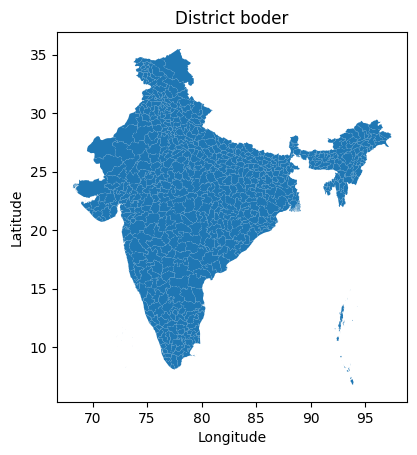

In [3]:
#Creating simple plot
df.plot()
plt.title("District boder")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [4]:
#Analysing data frame
print(df.head())

       GID_2 GID_0 COUNTRY    GID_1               NAME_1 NL_NAME_1  \
0  IND.1.1_1   IND   India  IND.1_1  Andaman and Nicobar        NA   
1  IND.1.2_1   IND   India  IND.1_1  Andaman and Nicobar        NA   
2  IND.1.3_1   IND   India  IND.1_1  Andaman and Nicobar        NA   
3  IND.2.1_1   IND   India  IND.2_1       Andhra Pradesh        NA   
4  IND.2.2_1   IND   India  IND.2_1       Andhra Pradesh        NA   

                     NAME_2             VARNAME_2 NL_NAME_2    TYPE_2  \
0           Nicobar Islands                    NA        NA  District   
1  North and Middle Andaman                    NA        NA  District   
2             South Andaman                    NA        NA  District   
3                 Anantapur  Anantpur, Ananthapur        NA  District   
4                  Chittoor       Chitoor|Chittor        NA  District   

  ENGTYPE_2 CC_2    HASC_2                                           geometry  
0  District   NA  IN.AN.NI  MULTIPOLYGON (((93.78988 6.85201

In [5]:
df.loc[df["NAME_2"]=="Faridabad"]

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
171,IND.12.3_1,IND,India,IND.12_1,Haryana,NA,Faridabad,NA,NA,District,District,NA,IN.HR.FD,"MULTIPOLYGON (((77.28564 27.89052, 77.28307 27..."


In [6]:
#Findig out the crs of the shp file
print(df.crs)

EPSG:4326


# Location's District

In [7]:
Lat = 26.91
Lng = 75.78

Location = Point(Lng,Lat)
Pin = gpd.GeoDataFrame(geometry=[Location], crs="EPSG:4326")


#Finding where Pin exactily drops
answer = gpd.sjoin(Pin, df, how='left', predicate='within')
district = answer.iloc[0]["NAME_2"]
print(district)

Jaipur


# Highlighting District

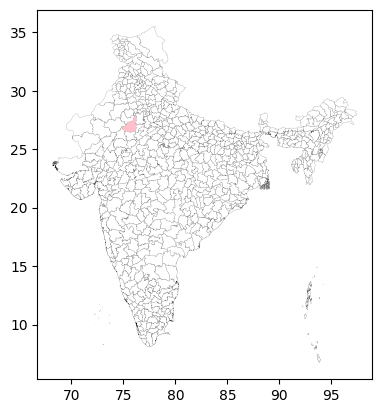

In [8]:
#Map creation
map = df.plot(color='white', edgecolor='black', linewidth=0.08) #Modifying map attributes.
chosen = df[df["NAME_2"] == district] #Selecting the subject row from df.
chosen.plot(ax=map, color='pink')
plt.show()

# Agro-Ecological Zones GIS data

# Setting up

In [9]:
AgroDF = gpd.read_file("/content/drive/MyDrive/Projects/Trial/Agriculture/Data/Agro_Ecological_regions.zip")
print("Setup complete!")

Setup complete!


# Data Exploration

In [10]:
print(AgroDF.head())

   objectid  ae_regcode                                         physio_reg  \
0         1           1            WESTERN HIMALAYAS  COLD ARID ECO-REGION   
1         2           2  WESTERN PLAIN  KACHCHH AND PART OF KATHIAWAR P...   
2         3           3        KARNATAKA PLATEAU (RAYALSEEMA AS INCLUSION)   
3         4           4  NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...   
4         5           5  CENTRAL HIGHLANDS ( MALWA )  GUJARAT PLAIN AND...   

       area_sqkm    shape_Leng    shape_Area  \
0   80785.506157  2.795579e+06  1.308765e+11   
1  131613.404490  6.391218e+06  3.135134e+11   
2   47540.891271  1.396622e+06  4.852203e+10   
3  116243.738067  5.782906e+06  3.006675e+11   
4    5613.884352  4.006328e+06  1.696862e+11   

                                            geometry  
0  POLYGON ((3526567.481 5442686.476, 3526877.528...  
1  MULTIPOLYGON (((3515495.284 4743983.247, 35198...  
2  POLYGON ((3540859.447 3241817.081, 3541158.988...  
3  POLYGON ((3501207.7

In [15]:
#Checking Crs of both maps
print(df.crs)
print(AgroDF.crs)

EPSG:4326
PROJCS["WGS_1984_Lambert_Conformal_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.4729444],PARAMETER["standard_parallel_2",35.17280555],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


# CRS Conversion

In [16]:
#Reprojecting chosen to AgroDF crs
chosen_reprojected = chosen.to_crs(AgroDF.crs)
print(chosen_reprojected.crs)

PROJCS["WGS_1984_Lambert_Conformal_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.4729444],PARAMETER["standard_parallel_2",35.17280555],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


# Visualization

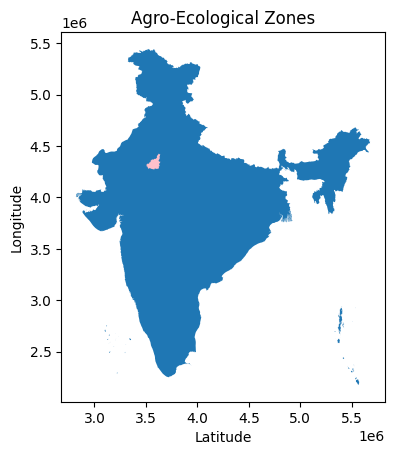

In [27]:
#ploting district from district .shp file on Agro-Ecological Zones map
AgroDF = AgroDF.dissolve() #Removing Internal Boundries
new_map = AgroDF.plot()
plt.title("Agro-Ecological Zones")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
chosen_reprojected.plot(ax=new_map, color="pink")
plt.show()

# Creating outline map of India

In [ ]:
'''The plan is to only keep only keep the outline of the
India and dissolving the internial bounderies marking
different zones in AgroDF'''
